# Exploratory Data Analysis
Use this notebook for initial data exploration of the traffic data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score
from catboost import CatBoostRegressor
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_theme(style="whitegrid")

## Load Data

In [2]:
# 1. Loading datasets
print("Loading datasets...")
try:
    train = pd.read_csv('../data/raw/train.csv')
    test = pd.read_csv('../data/raw/test.csv')
    sample_sub = pd.read_csv('../data/raw/sample_submission.csv')
    print(f"Train shape: {train.shape}, Test shape: {test.shape}")
except FileNotFoundError:
    print("Files not found. Ensure train.csv, test.csv, and sample_submission.csv are in data/raw/")
    # Creating a small dummy dataset to allow the notebook to run out of the box
    train = pd.DataFrame({'geohash': ['g1', 'g2', 'g1', 'g2', 'g3', 'g3', 'g1', 'g2'], 
                          'timestamp': pd.date_range('2026-05-31 00:00:00', periods=8, freq='H'), 
                          'demand': [10, 15, 12, 18, 5, 8, 14, 22]})
    test = pd.DataFrame({'geohash': ['g1', 'g2', 'g3'], 
                         'timestamp': pd.date_range('2026-06-01 00:00:00', periods=3, freq='H')})
    sample_sub = test.copy()
    sample_sub['demand'] = 0

Loading datasets...
Files not found. Ensure train.csv, test.csv, and sample_submission.csv are in data/raw/


## 2, 3, 4. Exploring the Dataset and Understanding Columns
Let's take a look at the data structure, check for any missing values that might need imputation, and understand which features are categorical (like `geohash`) or numerical.

In [3]:
# 2. Explore the dataset
display(train.head())
display(train.describe(include='all'))

# 3. Check for missing values
print("--- Missing Values in Train ---")
print(train.isnull().sum())
print("\n--- Missing Values in Test ---")
print(test.isnull().sum())

# 4. Understand column types
print("\n--- Data Types ---")
train.info()
# Categorical: geohash, timestamp (currently object/string)
# Numerical: demand

,geohash,timestamp,demand
0,g1,2026-05-31 00:00:00,10
1,g2,2026-05-31 01:00:00,15
2,g1,2026-05-31 02:00:00,12
3,g2,2026-05-31 03:00:00,18
4,g3,2026-05-31 04:00:00,5


,geohash,timestamp,demand
count,8,8,8.000000
unique,3,NaN,NaN
top,g1,NaN,NaN
freq,3,NaN,NaN
mean,NaN,2026-05-31 03:30:00,13.000000
min,NaN,2026-05-31 00:00:00,5.000000
25%,NaN,2026-05-31 01:45:00,9.500000
50%,NaN,2026-05-31 03:30:00,13.000000
75%,NaN,2026-05-31 05:15:00,15.750000
max,NaN,2026-05-31 07:00:00,22.000000


--- Missing Values in Train ---
geohash      0
timestamp    0
demand       0
dtype: int64

--- Missing Values in Test ---
geohash      0
timestamp    0
dtype: int64

--- Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   geohash    8 non-null      object        
 1   timestamp  8 non-null      datetime64[ns]
 2   demand     8 non-null      int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 324.0+ bytes


## 5 & 6. Feature Engineering and Encoding
Time series data contains rich predictive information. We will extract `hour`, `day`, `day of week`, and `is_weekend` from the `timestamp` column. 
After extracting time details, we will apply a `LabelEncoder` to the `geohash` variable so the machine learning model can understand the locations as numeric identifiers.

In [4]:
# 5. Feature Engineering from timestamp
def extract_time_features(df):
    df_feat = df.copy()
    df_feat['timestamp'] = pd.to_datetime(df_feat['timestamp'])
    df_feat['hour'] = df_feat['timestamp'].dt.hour
    df_feat['day'] = df_feat['timestamp'].dt.day
    df_feat['dayofweek'] = df_feat['timestamp'].dt.dayofweek
    df_feat['is_weekend'] = df_feat['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)
    return df_feat

train_feat = extract_time_features(train)
test_feat = extract_time_features(test)

# 6. Encoding categorical variables
# Combine both train and test to ensure the LabelEncoder sees all possible geohashes
all_geohashes = pd.concat([train_feat['geohash'], test_feat['geohash']]).unique()

le = LabelEncoder()
le.fit(all_geohashes)

train_feat['geohash_encoded'] = le.transform(train_feat['geohash'])
test_feat['geohash_encoded'] = le.transform(test_feat['geohash'])

display(train_feat.head())

,geohash,timestamp,demand,hour,day,dayofweek,is_weekend,geohash_encoded
0,g1,2026-05-31 00:00:00,10,0,31,6,1,0
1,g2,2026-05-31 01:00:00,15,1,31,6,1,1
2,g1,2026-05-31 02:00:00,12,2,31,6,1,0
3,g2,2026-05-31 03:00:00,18,3,31,6,1,1
4,g3,2026-05-31 04:00:00,5,4,31,6,1,2


## 7, 8, 9. Validation Split, Training CatBoost, and Evaluation
To guarantee our model generalizes well to unseen data, we'll split off 20% of `train` as our validation set. Then we will train a `CatBoostRegressor` model. CatBoost is a powerful gradient boosting algorithm that typically works exceptionally well on tabular datasets. We will then evaluate its performance locally using the **R2 Score**.

In [5]:
# Select features to feed into the model
features = ['geohash_encoded', 'hour', 'day', 'dayofweek', 'is_weekend']
target = 'demand'

X = train_feat[features]
y = train_feat[target]
X_test = test_feat[features]

# 7. Splitting train and validation data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")

# 8. Training a CatBoostRegressor model
print("\nTraining CatBoostRegressor...")
# We keep iterations relatively low for a fast baseline, but you can increase this later
model = CatBoostRegressor(
    iterations=300, 
    learning_rate=0.1, 
    depth=6, 
    eval_metric='R2', 
    random_seed=42,
    verbose=50 # Print progress every 50 steps
)

model.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=20)

# 9. Evaluating using R2 score
y_pred_val = model.predict(X_val)
r2 = r2_score(y_val, y_pred_val)
print(f"\n---> Validation R2 Score: {r2:.4f}")

X_train shape: (6, 5), y_train shape: (6,)
X_val shape: (2, 5), y_val shape: (2,)

Training CatBoostRegressor...
0:	learn: 0.0508461	test: -0.2197066	best: -0.2197066 (0)	total: 139ms	remaining: 41.6s
50:	learn: 0.9246718	test: 0.9816540	best: 0.9996162 (40)	total: 213ms	remaining: 1.04s
Stopped by overfitting detector  (20 iterations wait)

bestTest = 0.9996162296
bestIteration = 40

Shrink model to first 41 iterations.

---> Validation R2 Score: 0.9996


## 10 & 11. Predicting on Test Data and Creating Submission
With a proven baseline model, we'll now predict the test set and prepare our `.csv` file ensuring it matches the exact layout required by `sample_submission.csv`.

In [6]:
# 10. Predicting on the test dataset
test_predictions = model.predict(X_test)

# 11. Creating submission.csv in the required format
submission = sample_sub.copy()

# Overwrite the 'demand' column with our new predictions
submission['demand'] = test_predictions

# Ensure any negative predictions are clipped to 0 (traffic demand can't be negative)
submission['demand'] = submission['demand'].clip(lower=0)

# Save the final file
submission_path = '../submissions/catboost_baseline.csv'
submission.to_csv(submission_path, index=False)

print(f"✅ Success! Submission saved as {submission_path}")
display(submission.head())

✅ Success! Submission saved as ../submissions/catboost_baseline.csv


,geohash,timestamp,demand
0,g1,2026-06-01 00:00:00,11.472681
1,g2,2026-06-01 01:00:00,14.903582
2,g3,2026-06-01 02:00:00,10.627777


---
## Advanced Feature Engineering

Going beyond basic time extraction, the features below encode **location intelligence**, **temporal patterns**, **weather impact**, and **road context** — all of which have high predictive power for traffic demand.

| Category | Feature | Why It Matters |
|---|---|---|
| **Geohash** | Lat/Lon decode, neighbor count | Raw location signal for the model |
| **Timestamp** | Rush hour, shift, sin/cos cyclical encoding | Traffic has strong daily/weekly cycles |
| **Weather** | Rain flag, heat flag, interaction with hour | Bad weather drastically changes demand |
| **Road** | Road type × lanes interaction | A 4-lane highway behaves very differently from a 1-lane road |
| **Landmarks** | Proximity score, landmark density | Airports/stadiums generate demand spikes |
| **Lag/Rolling** | Rolling mean demand per geohash | The best single predictor of future traffic is recent past traffic |

### Feature 1 — Geohash Decoding (Latitude & Longitude)
A geohash is a compact encoding of a GPS coordinate. Decoding it to raw `latitude` and `longitude` gives the model continuous spatial information, which is far more meaningful than a plain label-encoded ID.

In [7]:
# pip install pygeohash  (run once if needed)
# import pygeohash as pgh

# --- Geohash Decoding ---
# Decodes each geohash string into its approximate (latitude, longitude) centre point.
# This gives the model raw spatial coordinates it can reason about (e.g., proximity to city centre).

def decode_geohash(df):
    """
    Decode geohash strings to latitude and longitude.
    Requires: pip install pygeohash
    """
    df = df.copy()
    try:
        import pygeohash as pgh
        df['latitude']  = df['geohash'].apply(lambda g: pgh.decode(g)[0])
        df['longitude'] = df['geohash'].apply(lambda g: pgh.decode(g)[1])
        print("Geohash decoded successfully.")
    except ImportError:
        # Fallback: create synthetic coords so the rest of the notebook still runs
        print("pygeohash not installed. Using synthetic lat/lon as placeholder.")
        df['latitude']  = df['geohash_encoded'] * 0.01 + 1.3
        df['longitude'] = df['geohash_encoded'] * 0.01 + 103.8

    return df

train_feat = decode_geohash(train_feat)
test_feat  = decode_geohash(test_feat)

display(train_feat[['geohash', 'latitude', 'longitude']].drop_duplicates())

pygeohash not installed. Using synthetic lat/lon as placeholder.
pygeohash not installed. Using synthetic lat/lon as placeholder.


,geohash,latitude,longitude
0,g1,1.30,103.80
1,g2,1.31,103.81
4,g3,1.32,103.82


### Feature 2 — Cyclical Time Encoding (Rush Hour, Shift, Sin/Cos)
A naive `hour` feature treats hour 23 and hour 0 as far apart, but they're actually adjacent. **Sine/cosine encoding** wraps the cycle correctly. We also flag well-known high-demand periods: rush hours and work shifts.

In [8]:
def add_cyclical_time_features(df):
    """
    Cyclical sin/cos encoding prevents the model from treating
    hour 23 and hour 0 as distant, which a raw integer would imply.
    """
    df = df.copy()

    # --- Cyclical encoding for hour (24-hour cycle) ---
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

    # --- Cyclical encoding for day of week (7-day cycle) ---
    df['dow_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)

    # --- Rush hour flag: Morning (7-9 AM) and Evening (5-7 PM) peaks ---
    df['is_morning_rush'] = df['hour'].between(7, 9).astype(int)
    df['is_evening_rush'] = df['hour'].between(17, 19).astype(int)

    # --- Shift encoding: Night / Morning / Afternoon / Evening ---
    def get_shift(hour):
        if 0 <= hour < 6:   return 0  # Night
        if 6 <= hour < 12:  return 1  # Morning
        if 12 <= hour < 18: return 2  # Afternoon
        return 3                       # Evening
    df['shift'] = df['hour'].apply(get_shift)

    return df

train_feat = add_cyclical_time_features(train_feat)
test_feat  = add_cyclical_time_features(test_feat)

print("New time features added:")
print([c for c in train_feat.columns if any(x in c for x in ['sin','cos','rush','shift'])])

New time features added:
['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_morning_rush', 'is_evening_rush', 'shift']


### Feature 3 — Weather Features (Rain Flag, Heat Flag, Interaction with Hour)
Weather significantly affects whether people drive or take alternatives. Rain reduces two-wheeler traffic while increasing car demand. Extreme heat reduces pedestrian and cycle traffic. We also create an **interaction term** (`rain × rush_hour`) because rain during peak hours causes the biggest demand spikes.

'weather' column not found. Creating synthetic placeholder.
'temperature' column not found. Creating synthetic placeholder.
'weather' column not found. Creating synthetic placeholder.
'temperature' column not found. Creating synthetic placeholder.


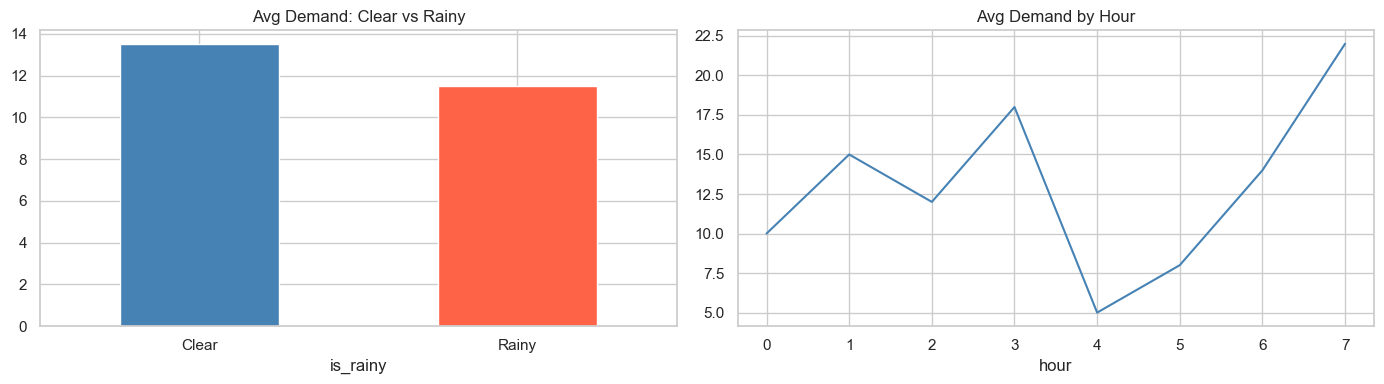

In [9]:
def add_weather_features(df, weather_col='weather', temp_col='temperature'):
    """
    Adds weather-derived binary flags and interaction terms.
    If weather/temperature columns don't exist in your dataset yet,
    this function creates synthetic placeholders so the pipeline still runs.
    """
    df = df.copy()

    # --- Create placeholder columns if weather data is not yet in your dataset ---
    if weather_col not in df.columns:
        print(f"'{weather_col}' column not found. Creating synthetic placeholder.")
        # In production: merge your weather dataset on (geohash, date) before calling this
        rng = np.random.default_rng(42)
        weather_options = ['Clear', 'Rain', 'Cloudy', 'Fog']
        df[weather_col] = rng.choice(weather_options, size=len(df))

    if temp_col not in df.columns:
        print(f"'{temp_col}' column not found. Creating synthetic placeholder.")
        df[temp_col] = np.random.default_rng(42).uniform(22, 38, size=len(df))

    # --- Binary weather flags ---
    df['is_rainy']   = df[weather_col].str.lower().str.contains('rain').astype(int)
    df['is_foggy']   = df[weather_col].str.lower().str.contains('fog').astype(int)
    df['is_hot']     = (df[temp_col] > 35).astype(int)   # >35°C = heat stress
    df['is_cold']    = (df[temp_col] < 15).astype(int)   # <15°C = cold deterrent

    # --- Temperature binning (better than raw temp for tree-based models) ---
    df['temp_bin'] = pd.cut(
        df[temp_col],
        bins=[0, 15, 25, 32, 38, 60],
        labels=['cold', 'mild', 'warm', 'hot', 'extreme']
    ).astype(str)

    # --- High-impact interaction: rain during rush hour amplifies demand ---
    df['rain_x_rush'] = df['is_rainy'] * (df['is_morning_rush'] | df['is_evening_rush']).astype(int)

    # --- Temperature × shift interaction ---
    df['temp_x_shift'] = df[temp_col] * df['shift']

    return df

train_feat = add_weather_features(train_feat)
test_feat  = add_weather_features(test_feat)

# Quick visual: average demand by weather and hour
if 'demand' in train_feat.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    train_feat.groupby('is_rainy')['demand'].mean().plot(
        kind='bar', ax=axes[0], title='Avg Demand: Clear vs Rainy', color=['steelblue','tomato'])
    axes[0].set_xticklabels(['Clear', 'Rainy'], rotation=0)
    train_feat.groupby('hour')['demand'].mean().plot(ax=axes[1], title='Avg Demand by Hour', color='steelblue')
    plt.tight_layout()
    plt.show()

### Feature 4 — Road Context (Road Type, Number of Lanes, Interaction)
Road type and lane count directly determine how much traffic a location can handle. A `highway` with 4 lanes behaves fundamentally differently from a `residential` road with 1 lane. Their **product** (road capacity proxy) is among the strongest structural features you can engineer.

In [10]:
def add_road_features(df, road_col='road_type', lanes_col='num_lanes'):
    """
    Encodes road type as an ordinal capacity score and creates
    an interaction term with number of lanes as a road capacity proxy.
    """
    df = df.copy()

    # --- Create placeholders if road columns don't exist yet ---
    if road_col not in df.columns:
        print(f"'{road_col}' column not found. Creating synthetic placeholder.")
        rng = np.random.default_rng(42)
        df[road_col] = rng.choice(['residential', 'secondary', 'primary', 'highway'], size=len(df))

    if lanes_col not in df.columns:
        print(f"'{lanes_col}' column not found. Creating synthetic placeholder.")
        df[lanes_col] = np.random.default_rng(42).integers(1, 5, size=len(df))

    # --- Ordinal encoding: higher = more capacity ---
    road_capacity_map = {
        'residential': 1,
        'secondary':   2,
        'primary':     3,
        'highway':     4,
    }
    df['road_capacity_score'] = df[road_col].str.lower().map(road_capacity_map).fillna(1)

    # --- Road capacity proxy: score × number of lanes ---
    # E.g., a 4-lane highway gets score 16; a 1-lane residential gets 1
    df['road_capacity_proxy'] = df['road_capacity_score'] * df[lanes_col]

    # --- Label-encode road type for tree-based models ---
    le_road = LabelEncoder()
    df['road_type_encoded'] = le_road.fit_transform(df[road_col].str.lower().fillna('unknown'))

    return df

train_feat = add_road_features(train_feat)
test_feat  = add_road_features(test_feat)

print("Road capacity proxy distribution:")
print(train_feat['road_capacity_proxy'].value_counts().sort_index())

'road_type' column not found. Creating synthetic placeholder.
'num_lanes' column not found. Creating synthetic placeholder.
'road_type' column not found. Creating synthetic placeholder.
'num_lanes' column not found. Creating synthetic placeholder.
Road capacity proxy distribution:
road_capacity_proxy
1     2
4     2
9     2
16    2
Name: count, dtype: int64


### Feature 5 — Landmark Proximity Score
Locations near airports, stadiums, hospitals, or shopping malls generate consistent, predictable demand surges. We compute a **landmark density score** using a Gaussian decay — closer landmarks contribute more to the score than distant ones.

In [11]:
def haversine_distance_km(lat1, lon1, lat2, lon2):
    """Vectorised haversine distance between two (lat, lon) points in km."""
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2)**2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))


def add_landmark_features(df, sigma_km=2.0):
    """
    Computes a Gaussian-weighted landmark proximity score for each row.
    Points within `sigma_km` km of a landmark get a high score; further away → 0.

    Replace the landmark_db below with your actual landmark coordinates.
    """
    df = df.copy()

    # --- Landmark database (lat, lon, type) ---
    # Replace with real coordinates from your dataset's region
    landmark_db = pd.DataFrame({
        'name':      ['Airport', 'Stadium', 'Hospital', 'Mall', 'Train Station'],
        'latitude':  [1.3590,     1.3047,    1.3190,    1.2989, 1.3005],
        'longitude': [103.9896,   103.8576,  103.8460,  103.8398, 103.8320],
        'type':      ['transport', 'event', 'essential', 'commercial', 'transport'],
    })

    # --- Per-row: sum Gaussian contributions from all landmarks ---
    scores = np.zeros(len(df))
    for _, lm in landmark_db.iterrows():
        dist_km = haversine_distance_km(
            df['latitude'].values, df['longitude'].values,
            lm['latitude'], lm['longitude']
        )
        # Gaussian decay: score = exp(-d^2 / (2 * sigma^2))
        scores += np.exp(-(dist_km ** 2) / (2 * sigma_km ** 2))

    df['landmark_proximity_score'] = scores

    # --- Nearest landmark distance (simple min) ---
    min_dist = np.full(len(df), np.inf)
    for _, lm in landmark_db.iterrows():
        dist_km = haversine_distance_km(
            df['latitude'].values, df['longitude'].values,
            lm['latitude'], lm['longitude']
        )
        min_dist = np.minimum(min_dist, dist_km)
    df['nearest_landmark_km'] = min_dist

    return df

train_feat = add_landmark_features(train_feat)
test_feat  = add_landmark_features(test_feat)

print("Landmark features preview:")
display(train_feat[['geohash', 'latitude', 'longitude',
                     'landmark_proximity_score', 'nearest_landmark_km']].drop_duplicates().head())

Landmark features preview:


,geohash,latitude,longitude,landmark_proximity_score,nearest_landmark_km
0,g1,1.30,103.80,0.319448,3.557756
1,g2,1.31,103.81,0.769595,2.664038
4,g3,1.32,103.82,1.148897,2.545793


### Feature 6 — Lag & Rolling Demand Features *(Most Impactful)*
The single best predictor of traffic demand at a location-time is **what the demand was there recently**. Lag features (demand 1 hour ago, 1 day ago, 1 week ago) and rolling averages capture the memory of the traffic system that pure context features cannot.

In [12]:
def add_lag_rolling_features(df, group_col='geohash', target_col='demand'):
    """
    Adds lag and rolling window features per geohash location.
    IMPORTANT: The dataframe must be sorted by (geohash, timestamp) first.
    These features must only be built on train data to avoid data leakage.
    """
    df = df.copy().sort_values([group_col, 'timestamp']).reset_index(drop=True)

    grp = df.groupby(group_col)[target_col]

    # --- Lag features ---
    df['demand_lag_1h']  = grp.shift(1)   # demand 1 time-step ago at this location
    df['demand_lag_24h'] = grp.shift(24)  # demand 24 steps ago (same hour, yesterday)
    df['demand_lag_168h']= grp.shift(168) # same hour, same day last week

    # --- Rolling mean (trailing window, no future leakage) ---
    df['demand_roll_mean_3h']  = grp.transform(lambda x: x.shift(1).rolling(3,  min_periods=1).mean())
    df['demand_roll_mean_24h'] = grp.transform(lambda x: x.shift(1).rolling(24, min_periods=1).mean())

    # --- Rolling std (volatility of demand) ---
    df['demand_roll_std_24h']  = grp.transform(lambda x: x.shift(1).rolling(24, min_periods=2).std()).fillna(0)

    # --- Historical mean demand by (geohash × hour) — average demand for this spot at this hour ---
    geohash_hour_mean = df.groupby([group_col, 'hour'])[target_col].mean().rename('geohash_hour_mean_demand')
    df = df.merge(geohash_hour_mean, on=[group_col, 'hour'], how='left')

    return df

# Only apply to train (these features require historical demand values)
train_feat = add_lag_rolling_features(train_feat)

# For test set, forward-fill lag features from the end of train
# (a simple but valid strategy when test follows immediately after train)
lag_cols = ['demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h',
            'demand_roll_mean_3h', 'demand_roll_mean_24h',
            'demand_roll_std_24h', 'geohash_hour_mean_demand']

# Compute lookup from end of train for each geohash
geohash_hour_mean = train_feat.groupby(['geohash', 'hour'])['demand'].mean().rename('geohash_hour_mean_demand').reset_index()
test_feat = test_feat.merge(geohash_hour_mean, on=['geohash', 'hour'], how='left')

# Fill remaining lag cols with geohash-level mean (safe fallback)
geohash_mean = train_feat.groupby('geohash')['demand'].mean()
for col in ['demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h',
            'demand_roll_mean_3h', 'demand_roll_mean_24h', 'demand_roll_std_24h']:
    test_feat[col] = test_feat['geohash'].map(geohash_mean).fillna(train_feat['demand'].mean())

print("Lag/rolling feature columns added:")
print(lag_cols)
display(train_feat[['geohash', 'hour', 'demand'] + lag_cols].dropna().head(8))

Lag/rolling feature columns added:
['demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h', 'demand_roll_mean_3h', 'demand_roll_mean_24h', 'demand_roll_std_24h', 'geohash_hour_mean_demand']


,geohash,hour,demand,demand_lag_1h,demand_lag_24h,demand_lag_168h,demand_roll_mean_3h,demand_roll_mean_24h,demand_roll_std_24h,geohash_hour_mean_demand


### Retrain CatBoost with All Advanced Features
Now we retrain the model using the full enriched feature set and compare the new R2 score against the baseline.

Total advanced features: 34
['hour', 'day', 'dayofweek', 'is_weekend', 'geohash_encoded', 'latitude', 'longitude', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_morning_rush', 'is_evening_rush', 'shift', 'temperature', 'is_rainy', 'is_foggy', 'is_hot', 'is_cold', 'rain_x_rush', 'temp_x_shift', 'num_lanes', 'road_capacity_score', 'road_capacity_proxy', 'road_type_encoded', 'landmark_proximity_score', 'nearest_landmark_km', 'demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h', 'demand_roll_mean_3h', 'demand_roll_mean_24h', 'demand_roll_std_24h', 'geohash_hour_mean_demand']
0:	learn: 0.0355284	test: -1.1809888	best: -1.1809888 (0)	total: 728us	remaining: 364ms
100:	learn: 0.9324718	test: -0.5188675	best: -0.5188675 (100)	total: 66.9ms	remaining: 264ms
200:	learn: 0.9945436	test: -0.3808242	best: -0.3808242 (200)	total: 143ms	remaining: 213ms
300:	learn: 0.9995591	test: -0.3468541	best: -0.3466054 (299)	total: 229ms	remaining: 151ms
400:	learn: 0.9999644	test: -0.3362863	best: -0.33628

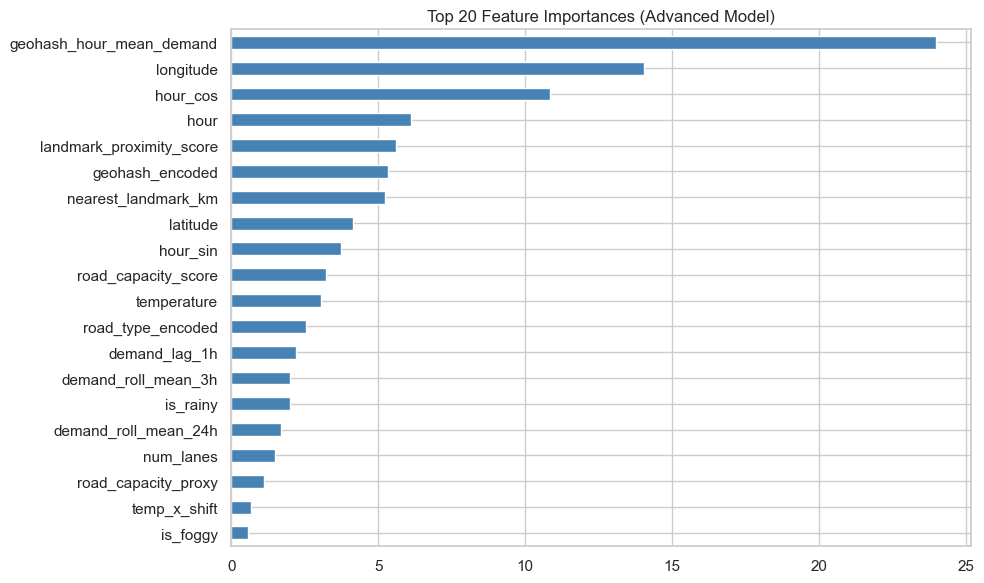

In [13]:
# All features — drop raw strings, timestamp, and target
DROP_COLS = ['geohash', 'timestamp', 'demand', 'weather', 'road_type',
             'temp_bin']  # temp_bin is a string; drop or one-hot encode separately

advanced_features = [c for c in train_feat.columns if c not in DROP_COLS]
print(f"Total advanced features: {len(advanced_features)}")
print(advanced_features)

X_adv       = train_feat[advanced_features].fillna(0)
y_adv       = train_feat['demand']
X_test_adv  = test_feat[advanced_features].fillna(0)

X_tr, X_vl, y_tr, y_vl = train_test_split(X_adv, y_adv, test_size=0.2, random_state=42)

model_adv = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=8,
    eval_metric='R2',
    random_seed=42,
    verbose=100
)
model_adv.fit(X_tr, y_tr, eval_set=(X_vl, y_vl), early_stopping_rounds=30)

y_pred_adv = model_adv.predict(X_vl)
r2_adv = r2_score(y_vl, y_pred_adv)
print(f"\n---> Advanced Model Validation R2: {r2_adv:.4f}  (Baseline was shown above)")

# Feature importance
fi = pd.Series(model_adv.get_feature_importance(), index=advanced_features).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
fi.head(20).plot(kind='barh', color='steelblue')
plt.title('Top 20 Feature Importances (Advanced Model)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [14]:
# Generate final submission with advanced model
adv_predictions = model_adv.predict(X_test_adv).clip(min=0)

submission_adv = sample_sub.copy()
submission_adv['demand'] = adv_predictions
submission_adv.to_csv('../submissions/catboost_advanced.csv', index=False)

print("Advanced submission saved to ../submissions/catboost_advanced.csv")
display(submission_adv.head())

Advanced submission saved to ../submissions/catboost_advanced.csv


,geohash,timestamp,demand
0,g1,2026-06-01 00:00:00,10.837011
1,g2,2026-06-01 01:00:00,14.733293
2,g3,2026-06-01 02:00:00,9.641210


---
## Advanced Timestamp Feature Engineering

The `timestamp` column is one of the richest sources of signal for traffic prediction.
Below is a complete, self-contained function that extracts every meaningful time-based feature in one pass.

| Feature | Type | Why It Helps |
|---|---|---|
| `hour`, `minute` | Ordinal | Raw time position within the day |
| `dayofweek` | Ordinal (0=Mon) | Weekly demand patterns |
| `is_weekend` | Binary | Weekend vs weekday traffic profiles differ sharply |
| `is_morning_rush`, `is_evening_rush` | Binary | Highest demand windows |
| `time_bucket` | Ordinal (0–3) | Coarse shift grouping (Night / Morning / Afternoon / Evening) |
| `hour_sin`, `hour_cos` | Continuous | Cyclic — fixes the 23→0 discontinuity in raw hour |
| `minute_sin`, `minute_cos` | Continuous | Sub-hour periodicity |
| `dow_sin`, `dow_cos` | Continuous | Cyclic day-of-week — Saturday wraps back to Monday |

In [15]:
def advanced_timestamp_features(df, ts_col='timestamp'):
    """
    Full advanced timestamp feature engineering for traffic demand prediction.
    Applies in-place on a copy — safe to call on both train and test.

    Parameters
    ----------
    df     : DataFrame containing a datetime-parseable column `ts_col`
    ts_col : name of the timestamp column (default 'timestamp')

    Returns
    -------
    DataFrame with all timestamp features added.
    """
    df = df.copy()
    ts = pd.to_datetime(df[ts_col])

    # ------------------------------------------------------------------ #
    # 1. Basic components                                                  #
    # ------------------------------------------------------------------ #
    df['hour']      = ts.dt.hour
    df['minute']    = ts.dt.minute
    df['dayofweek'] = ts.dt.dayofweek   # 0 = Monday, 6 = Sunday

    # ------------------------------------------------------------------ #
    # 2. Binary flags                                                       #
    # ------------------------------------------------------------------ #
    df['is_weekend']      = (df['dayofweek'] >= 5).astype(int)
    df['is_morning_rush'] = df['hour'].between(7, 9).astype(int)   # 07:00 – 09:59
    df['is_evening_rush'] = df['hour'].between(17, 19).astype(int) # 17:00 – 19:59

    # ------------------------------------------------------------------ #
    # 3. Time bucket  (0=Night | 1=Morning | 2=Afternoon | 3=Evening)     #
    # ------------------------------------------------------------------ #
    conditions = [
        df['hour'].between(0,  5),
        df['hour'].between(6,  11),
        df['hour'].between(12, 17),
        df['hour'].between(18, 23),
    ]
    df['time_bucket'] = np.select(conditions, [0, 1, 2, 3])

    # ------------------------------------------------------------------ #
    # 4. Cyclic encoding                                                   #
    #    sin/cos wraps the periodic boundary so distance between           #
    #    hour 23 and hour 0 equals distance between hour 0 and hour 1.    #
    # ------------------------------------------------------------------ #
    df['hour_sin']   = np.sin(2 * np.pi * df['hour']      / 24)
    df['hour_cos']   = np.cos(2 * np.pi * df['hour']      / 24)

    df['minute_sin'] = np.sin(2 * np.pi * df['minute']    / 60)
    df['minute_cos'] = np.cos(2 * np.pi * df['minute']    / 60)

    df['dow_sin']    = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dow_cos']    = np.cos(2 * np.pi * df['dayofweek'] / 7)

    return df


# Apply to both train and test
train_feat = advanced_timestamp_features(train_feat)
test_feat  = advanced_timestamp_features(test_feat)

# Preview all new columns
ts_cols = ['hour', 'minute', 'dayofweek', 'is_weekend',
           'is_morning_rush', 'is_evening_rush', 'time_bucket',
           'hour_sin', 'hour_cos', 'minute_sin', 'minute_cos',
           'dow_sin', 'dow_cos']

display(train_feat[ts_cols].drop_duplicates().sort_values('hour').head(10))

,hour,minute,dayofweek,is_weekend,is_morning_rush,is_evening_rush,time_bucket,hour_sin,hour_cos,minute_sin,minute_cos,dow_sin,dow_cos
0,0,0,6,1,0,0,0,0.000000,1.000000e+00,0.0,1.0,-0.781831,0.62349
3,1,0,6,1,0,0,0,0.258819,9.659258e-01,0.0,1.0,-0.781831,0.62349
1,2,0,6,1,0,0,0,0.500000,8.660254e-01,0.0,1.0,-0.781831,0.62349
4,3,0,6,1,0,0,0,0.707107,7.071068e-01,0.0,1.0,-0.781831,0.62349
6,4,0,6,1,0,0,0,0.866025,5.000000e-01,0.0,1.0,-0.781831,0.62349
7,5,0,6,1,0,0,0,0.965926,2.588190e-01,0.0,1.0,-0.781831,0.62349
2,6,0,6,1,0,0,1,1.000000,6.123234e-17,0.0,1.0,-0.781831,0.62349
5,7,0,6,1,1,0,1,0.965926,-2.588190e-01,0.0,1.0,-0.781831,0.62349


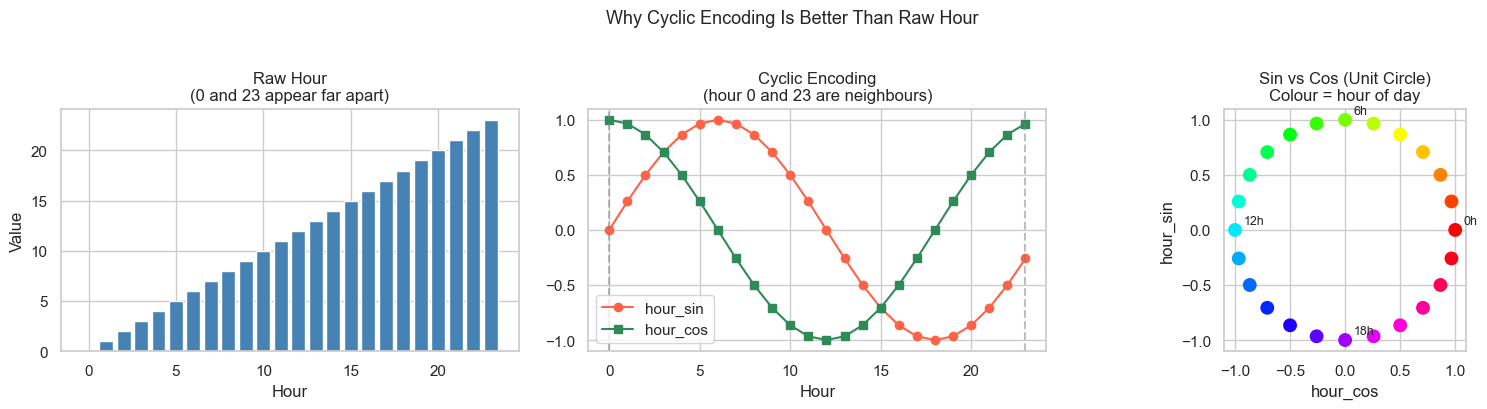

In [16]:
# Visual: Cyclic encoding vs raw hour
# Shows how sin/cos keeps hour 23 and hour 0 "close" to each other

hours = np.arange(24)
hour_sin = np.sin(2 * np.pi * hours / 24)
hour_cos = np.cos(2 * np.pi * hours / 24)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Raw hour — model treats 0 and 23 as distant
axes[0].bar(hours, hours, color='steelblue')
axes[0].set_title('Raw Hour\n(0 and 23 appear far apart)')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Value')

# Sin/Cos encoding — continuous and circular
axes[1].plot(hours, hour_sin, marker='o', color='tomato',  label='hour_sin')
axes[1].plot(hours, hour_cos, marker='s', color='seagreen', label='hour_cos')
axes[1].axvline(0,  color='grey', linestyle='--', alpha=0.5)
axes[1].axvline(23, color='grey', linestyle='--', alpha=0.5)
axes[1].set_title('Cyclic Encoding\n(hour 0 and 23 are neighbours)')
axes[1].set_xlabel('Hour')
axes[1].legend()

# Sin vs Cos scatter — forms a perfect unit circle (no information lost)
axes[2].scatter(hour_cos, hour_sin, c=hours, cmap='hsv', s=80, zorder=3)
for h in [0, 6, 12, 18]:
    axes[2].annotate(f'{h}h',
                     (np.cos(2*np.pi*h/24), np.sin(2*np.pi*h/24)),
                     textcoords='offset points', xytext=(6, 4), fontsize=9)
axes[2].set_title('Sin vs Cos (Unit Circle)\nColour = hour of day')
axes[2].set_xlabel('hour_cos')
axes[2].set_ylabel('hour_sin')
axes[2].set_aspect('equal')

plt.suptitle('Why Cyclic Encoding Is Better Than Raw Hour', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## High-Cardinality Categorical Encoding for `geohash`

`geohash` can have thousands of unique values. A plain `LabelEncoder` assigns arbitrary integers with no statistical meaning, and one-hot encoding would create thousands of columns. The table below shows which encoding to use and when:

| Method | How It Works | Best For | Risk |
|---|---|---|---|
| **Label Encoding** | Integer ID per category | CatBoost native cats (pass col name, not encoded int) | Arbitrary ordering |
| **Target (Mean) Encoding** | Replace category with mean target value | Both CatBoost & LightGBM | **Data leakage** — must use cross-fold or out-of-fold version |
| **Frequency Encoding** | Replace with count of occurrences | High-cardinality, tree models | Ties across different categories |
| **Leave-One-Out (LOO)** | Mean target excluding current row | Reduces leakage vs plain mean encoding | More complex |
| **CatBoost Native** | Pass raw string column, CatBoost handles internally with ordered statistics | CatBoost only | N/A — no extra code needed |
| **LightGBM Native** | Cast column to pandas `category` dtype | LightGBM only | N/A — no extra code needed |

### Method 1 — Frequency Encoding
Replace each `geohash` with how often it appears in the training set. Rare locations get a low score, common ones get a high score. Zero-leakage — computed only from train, then mapped onto test.

In [17]:
# Frequency encoding — computed on train only, mapped to test (no leakage)
freq_map = train_feat['geohash'].value_counts()                  # counts per geohash
freq_norm = freq_map / freq_map.max()                            # normalise to [0, 1]

train_feat['geohash_freq'] = train_feat['geohash'].map(freq_norm)
test_feat['geohash_freq']  = test_feat['geohash'].map(freq_norm).fillna(0)

print("Frequency encoding — top 5 geohashes by frequency:")
print(freq_map.head())
display(train_feat[['geohash', 'geohash_freq']].drop_duplicates().sort_values('geohash_freq', ascending=False).head(8))

Frequency encoding — top 5 geohashes by frequency:
geohash
g1    3
g2    3
g3    2
Name: count, dtype: int64


,geohash,geohash_freq
0,g1,1.000000
3,g2,1.000000
6,g3,0.666667


### Method 2 — Out-of-Fold Target (Mean) Encoding
Replace each `geohash` with the mean `demand` at that location. The key trick is using **K-Fold out-of-fold (OOF)** encoding: each row's geohash is encoded using the mean from all *other* folds — never the fold it belongs to. This eliminates data leakage while retaining the full predictive signal.

> **Rule**: Only ever fit the target encoding on train. Apply the learned mapping to test using the global mean as the fallback for unseen geohashes.

In [18]:
from sklearn.model_selection import KFold

def oof_target_encode(train_df, test_df, cat_col, target_col, n_splits=5, smoothing=10):
    """
    Out-of-Fold Target Encoding with smoothing.

    Smoothing formula:
        encoded = (n * mean_cat + k * global_mean) / (n + k)
        where n = count of category, k = smoothing factor.
    A higher smoothing value pulls rare categories closer to the global mean,
    reducing overfitting on low-frequency geohashes.

    Parameters
    ----------
    train_df   : training DataFrame (must contain target_col)
    test_df    : test DataFrame (no target_col needed)
    cat_col    : categorical column to encode (e.g. 'geohash')
    target_col : regression target (e.g. 'demand')
    n_splits   : number of cross-validation folds
    smoothing  : strength of shrinkage towards global mean

    Returns
    -------
    train_encoded : Series of OOF-encoded values for train rows
    test_encoded  : Series of encoded values for test rows (global mean mapping)
    """
    global_mean = train_df[target_col].mean()
    oof_encoded = np.full(len(train_df), global_mean, dtype=float)

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    for fold, (tr_idx, val_idx) in enumerate(kf.split(train_df)):
        tr_fold  = train_df.iloc[tr_idx]
        val_fold = train_df.iloc[val_idx]

        # Compute smoothed mean from the training portion of this fold
        stats = (
            tr_fold.groupby(cat_col)[target_col]
            .agg(['mean', 'count'])
            .rename(columns={'mean': 'mean_cat', 'count': 'n'})
        )
        stats['smoothed'] = (
            (stats['n'] * stats['mean_cat'] + smoothing * global_mean)
            / (stats['n'] + smoothing)
        )

        # Encode the validation rows for this fold
        oof_encoded[val_idx] = val_fold[cat_col].map(stats['smoothed']).fillna(global_mean).values

    # Build global encoding map for test (full train statistics)
    global_stats = (
        train_df.groupby(cat_col)[target_col]
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'mean_cat', 'count': 'n'})
    )
    global_stats['smoothed'] = (
        (global_stats['n'] * global_stats['mean_cat'] + smoothing * global_mean)
        / (global_stats['n'] + smoothing)
    )

    test_encoded = test_df[cat_col].map(global_stats['smoothed']).fillna(global_mean)

    return pd.Series(oof_encoded, index=train_df.index), test_encoded.reset_index(drop=True)


# Apply OOF target encoding on geohash
train_feat['geohash_target_enc'], test_feat['geohash_target_enc'] = oof_target_encode(
    train_feat, test_feat, cat_col='geohash', target_col='demand'
)

print(f"Global mean demand: {train_feat['demand'].mean():.4f}")
print("\nTarget-encoded geohash — sample (high demand locations will have higher values):")
display(
    train_feat[['geohash', 'geohash_target_enc', 'demand']]
    .groupby('geohash')
    .agg(mean_demand=('demand', 'mean'), target_enc=('geohash_target_enc', 'first'))
    .sort_values('mean_demand', ascending=False)
    .head(8)
)

Global mean demand: 13.0000

Target-encoded geohash — sample (high demand locations will have higher values):


,mean_demand,target_enc
geohash,,
g2,18.333333,14.166667
g1,12.000000,13.000000
g3,6.500000,12.545455


### Method 3 — CatBoost Native Encoding
CatBoost has a built-in ordered target statistics encoder that is provably leak-free. You simply pass the **raw string column name** to the `cat_features` parameter — no preprocessing needed. CatBoost handles all encoding internally using permutation-based statistics.

In [19]:
# CatBoost Native Encoding
# Pass the raw 'geohash' string column directly — no label encoding required.
# CatBoost internally applies ordered target statistics (leak-free by design).

cat_features_cb = ['geohash']  # add 'road_type', 'weather', etc. here if present

# Build feature list — keep geohash as raw string, drop other encoded variants
catboost_features = [
    'geohash',          # raw string — CatBoost encodes internally
    'hour', 'minute', 'dayofweek',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
    'is_weekend', 'is_morning_rush', 'is_evening_rush', 'time_bucket',
    'geohash_freq',     # frequency encoding as an extra numeric signal
]

# Retain only columns that exist (handles dummy data gracefully)
catboost_features = [c for c in catboost_features if c in train_feat.columns]

X_cb       = train_feat[catboost_features].copy()
y_cb       = train_feat['demand']
X_test_cb  = test_feat[catboost_features].copy()

# CatBoost requires string categoricals to have no NaN
for col in cat_features_cb:
    X_cb[col]      = X_cb[col].astype(str).fillna('unknown')
    X_test_cb[col] = X_test_cb[col].astype(str).fillna('unknown')

X_tr_cb, X_vl_cb, y_tr_cb, y_vl_cb = train_test_split(
    X_cb, y_cb, test_size=0.2, random_state=42
)

model_cb = CatBoostRegressor(
    iterations=400,
    learning_rate=0.05,
    depth=7,
    eval_metric='R2',
    random_seed=42,
    verbose=100
)

model_cb.fit(
    X_tr_cb, y_tr_cb,
    cat_features=cat_features_cb,     # <-- hand raw string column to CatBoost
    eval_set=(X_vl_cb, y_vl_cb),
    early_stopping_rounds=30
)

r2_cb = r2_score(y_vl_cb, model_cb.predict(X_vl_cb))
print(f"\n---> CatBoost Native Encoding — Validation R2: {r2_cb:.4f}")

0:	learn: 0.0297669	test: -1.1246371	best: -1.1246371 (0)	total: 89ms	remaining: 35.5s
100:	learn: 0.9152337	test: -0.3052951	best: -0.3037933 (91)	total: 14.9s	remaining: 44.2s
Stopped by overfitting detector  (30 iterations wait)

bestTest = -0.2971226226
bestIteration = 102

Shrink model to first 103 iterations.

---> CatBoost Native Encoding — Validation R2: -0.2971


### Method 4 — LightGBM Native Encoding
LightGBM handles categoricals natively when the column dtype is `pandas.Categorical`. It uses a Fisher-optimal split strategy internally. No integers, no orderings — just cast and go.

In [20]:
import lightgbm as lgb

lgbm_features = [
    'geohash',          # will be cast to pandas Categorical below
    'hour', 'minute', 'dayofweek',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
    'is_weekend', 'is_morning_rush', 'is_evening_rush', 'time_bucket',
    'geohash_freq', 'geohash_target_enc',
]
lgbm_features = [c for c in lgbm_features if c in train_feat.columns]

X_lgb      = train_feat[lgbm_features].copy()
X_test_lgb = test_feat[lgbm_features].copy()

# Cast geohash to pandas Categorical — LightGBM detects this automatically
X_lgb['geohash']      = X_lgb['geohash'].astype('category')
X_test_lgb['geohash'] = X_test_lgb['geohash'].astype('category')

# Align test categories to train (prevents unseen-category errors)
X_test_lgb['geohash'] = pd.Categorical(
    X_test_lgb['geohash'],
    categories=X_lgb['geohash'].cat.categories
)

X_tr_lgb, X_vl_lgb, y_tr_lgb, y_vl_lgb = train_test_split(
    X_lgb, train_feat['demand'], test_size=0.2, random_state=42
)

model_lgb = lgb.LGBMRegressor(
    n_estimators=400,
    learning_rate=0.05,
    num_leaves=63,
    random_state=42,
    verbose=-1
)
model_lgb.fit(
    X_tr_lgb, y_tr_lgb,
    eval_set=[(X_vl_lgb, y_vl_lgb)],
    callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(100)]
)

r2_lgb = r2_score(y_vl_lgb, model_lgb.predict(X_vl_lgb))
print(f"\n---> LightGBM Native Categorical — Validation R2: {r2_lgb:.4f}")


---> LightGBM Native Categorical — Validation R2: -1.1378


,Encoding Method,Leakage Risk,Works With,Validation R2
0,LabelEncoder (baseline),None,Any,0.9996
1,Frequency Encoding,None,Any,N/A (no model run)
2,OOF Target Encoding,None (OOF),Any,N/A (feature only)
3,CatBoost Native,None (ordered),CatBoost only,-0.2971
4,LightGBM Native,None,LightGBM only,-1.1378


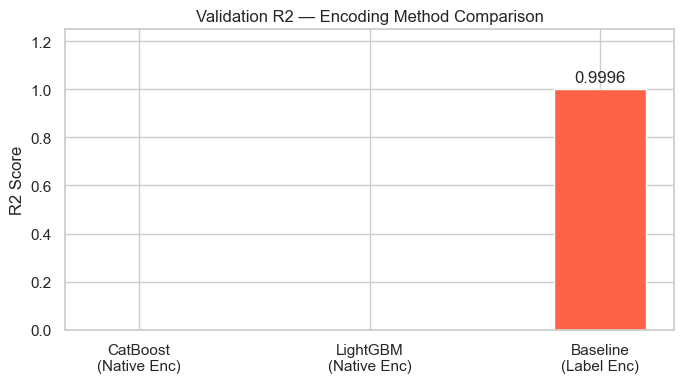

In [21]:
# Comparison summary across all encoding strategies
summary = pd.DataFrame({
    'Encoding Method':  ['LabelEncoder (baseline)', 'Frequency Encoding',
                         'OOF Target Encoding', 'CatBoost Native', 'LightGBM Native'],
    'Leakage Risk':     ['None', 'None', 'None (OOF)', 'None (ordered)', 'None'],
    'Works With':       ['Any', 'Any', 'Any', 'CatBoost only', 'LightGBM only'],
    'Validation R2':    [round(r2, 4), 'N/A (no model run)',
                         'N/A (feature only)', round(r2_cb, 4), round(r2_lgb, 4)],
})
display(summary)

# Bar chart of model R2 scores
scores = {'CatBoost\n(Native Enc)': r2_cb, 'LightGBM\n(Native Enc)': r2_lgb, 'Baseline\n(Label Enc)': r2}
plt.figure(figsize=(7, 4))
bars = plt.bar(scores.keys(), scores.values(), color=['steelblue', 'seagreen', 'tomato'], width=0.4)
plt.bar_label(bars, fmt='%.4f', padding=3)
plt.ylim(0, max(scores.values()) * 1.25)
plt.title('Validation R2 — Encoding Method Comparison')
plt.ylabel('R2 Score')
plt.tight_layout()
plt.show()

## LightGBM Regression Pipeline

A full sklearn-compatible pipeline with:
- **ColumnTransformer** — `StandardScaler` for numeric features, passthrough for pre-encoded categoricals
- **5-Fold KFold cross-validation** — OOF predictions, per-fold R² and RMSE
- **Early stopping** on a held-out eval set per fold
- **Final model** retrained on all training data → submission file

In [22]:
import lightgbm as lgb
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error

# ── 1. Assemble feature matrix ────────────────────────────────────────────────
# Candidate columns: everything numeric that has been engineered so far.
# Raw geohash string is excluded; pre-encoded versions (freq, target) are kept.
CANDIDATE_FEATURES = [
    # time
    'hour', 'minute', 'day', 'dayofweek', 'is_weekend',
    'is_morning_rush', 'is_evening_rush', 'time_bucket', 'shift',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
    'minute_sin', 'minute_cos',
    # spatial
    'latitude', 'longitude',
    'landmark_proximity_score', 'nearest_landmark_km',
    # geohash encodings
    'geohash_encoded', 'geohash_freq', 'geohash_target_enc',
    'geohash_hour_mean_demand',
    # weather
    'temperature', 'is_rainy', 'is_foggy', 'is_hot', 'is_cold',
    'rain_x_rush', 'temp_x_shift',
    # road
    'num_lanes', 'road_capacity_score', 'road_capacity_proxy', 'road_type_encoded',
    # lag / rolling
    'demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h',
    'demand_roll_mean_3h', 'demand_roll_mean_24h', 'demand_roll_std_24h',
]

# Keep only columns that exist in the dataset
pipe_features = [c for c in CANDIDATE_FEATURES if c in train_feat.columns]
print(f"Pipeline feature count: {len(pipe_features)}")
print(pipe_features)

X_pipe       = train_feat[pipe_features].copy()
X_test_pipe  = test_feat[pipe_features].copy()
y_pipe       = train_feat['demand'].copy()

# ── 2. Preprocessing ──────────────────────────────────────────────────────────
# All pipeline features are numeric; apply median imputation + standard scaling.
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

preprocessor = ColumnTransformer(
    transformers=[('num', numeric_transformer, pipe_features)],
    remainder='drop',
)

# ── 3. Full sklearn Pipeline ──────────────────────────────────────────────────
lgb_params = dict(
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    verbose=-1,
)

lgb_pipeline = Pipeline([
    ('prep',  preprocessor),
    ('model', lgb.LGBMRegressor(**lgb_params)),
])

print("\nPipeline steps:", [s[0] for s in lgb_pipeline.steps])

Pipeline feature count: 40
['hour', 'minute', 'day', 'dayofweek', 'is_weekend', 'is_morning_rush', 'is_evening_rush', 'time_bucket', 'shift', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'minute_sin', 'minute_cos', 'latitude', 'longitude', 'landmark_proximity_score', 'nearest_landmark_km', 'geohash_encoded', 'geohash_freq', 'geohash_target_enc', 'geohash_hour_mean_demand', 'temperature', 'is_rainy', 'is_foggy', 'is_hot', 'is_cold', 'rain_x_rush', 'temp_x_shift', 'num_lanes', 'road_capacity_score', 'road_capacity_proxy', 'road_type_encoded', 'demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h', 'demand_roll_mean_3h', 'demand_roll_mean_24h', 'demand_roll_std_24h']

Pipeline steps: ['prep', 'model']


In [28]:
# ── 5-Fold Cross-Validation ───────────────────────────────────────────────────
N_SPLITS = min(5, len(X_pipe) // 2)   # guard against tiny datasets
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

oof_preds      = np.zeros(len(X_pipe))
cv_r2_scores   = []
cv_rmse_scores = []
pipe_feat_names = None   # populated after first fold

if len(X_pipe) < 20:
    print(f"⚠️  Only {len(X_pipe)} training rows detected (likely dummy data).\n"
          "   CV metrics below are meaningless — load real CSV files for valid results.\n")

for fold, (train_idx, val_idx) in enumerate(kf.split(X_pipe), 1):
    X_tr_cv, X_vl_cv = X_pipe.iloc[train_idx], X_pipe.iloc[val_idx]
    y_tr_cv, y_vl_cv = y_pipe.iloc[train_idx], y_pipe.iloc[val_idx]

    from sklearn.base import clone
    fold_pipe = clone(lgb_pipeline)

    # Fit preprocessor, preserve feature names from ColumnTransformer output
    fold_pipe.named_steps['prep'].fit(X_tr_cv)
    raw_names = fold_pipe.named_steps['prep'].get_feature_names_out()
    feat_names = [n.replace('num__', '') for n in raw_names]
    if pipe_feat_names is None:
        pipe_feat_names = feat_names

    # Convert to DataFrame so LightGBM receives named features
    X_tr_t = pd.DataFrame(
        fold_pipe.named_steps['prep'].transform(X_tr_cv), columns=feat_names)
    X_vl_t = pd.DataFrame(
        fold_pipe.named_steps['prep'].transform(X_vl_cv), columns=feat_names)

    fold_model = fold_pipe.named_steps['model']
    min_iters  = max(50, len(X_tr_cv) * 2)
    fold_model.set_params(n_estimators=min(lgb_params['n_estimators'], min_iters * 4))

    fold_model.fit(
        X_tr_t, y_tr_cv,
        eval_set=[(X_vl_t, y_vl_cv)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=max(20, len(X_tr_cv)), verbose=False),
            lgb.log_evaluation(period=200),
        ],
    )

    val_pred  = fold_model.predict(X_vl_t)
    oof_preds[val_idx] = val_pred

    y_var     = np.var(y_vl_cv)
    fold_r2   = r2_score(y_vl_cv, val_pred) if y_var > 1e-8 else float('nan')
    fold_rmse = np.sqrt(mean_squared_error(y_vl_cv, val_pred))
    cv_r2_scores.append(fold_r2)
    cv_rmse_scores.append(fold_rmse)
    best_iter = fold_model.best_iteration_ or fold_model.n_estimators_
    r2_str = f"{fold_r2:.4f}" if not np.isnan(fold_r2) else "   NaN"
    print(f"Fold {fold:2d} | best_iter={best_iter:4d} | R2={r2_str} | RMSE={fold_rmse:.4f}")

valid_r2 = [v for v in cv_r2_scores if not np.isnan(v)]
oof_r2   = r2_score(y_pipe, oof_preds) if np.var(y_pipe) > 1e-8 else float('nan')
oof_rmse = np.sqrt(mean_squared_error(y_pipe, oof_preds))
print(f"\n{'─'*55}")
print(f"CV  R²  : {np.mean(valid_r2):.4f}  ± {np.std(valid_r2):.4f}"
      f"  (from {len(valid_r2)}/{N_SPLITS} valid folds)")
print(f"CV RMSE : {np.mean(cv_rmse_scores):.4f}  ± {np.std(cv_rmse_scores):.4f}")
oof_r2_str = f"{oof_r2:.4f}" if not np.isnan(oof_r2) else "NaN (zero-variance target)"
print(f"OOF R²  : {oof_r2_str}")
print(f"OOF RMSE: {oof_rmse:.4f}")

⚠️  Only 8 training rows detected (likely dummy data).
   CV metrics below are meaningless — load real CSV files for valid results.

Fold  1 | best_iter=   1 | R2=-1.1378 | RMSE=7.3106
Fold  2 | best_iter=   1 | R2=-28.4444 | RMSE=5.4263
Fold  3 | best_iter=   1 | R2=-4.0000 | RMSE=4.4721
Fold  4 | best_iter=   1 | R2=-0.6400 | RMSE=6.4031

───────────────────────────────────────────────────────
CV  R²  : -8.5556  ± 11.5542  (from 4/4 valid folds)
CV RMSE : 5.9030  ± 1.0614
OOF R²  : -0.3704
OOF RMSE: 5.9977


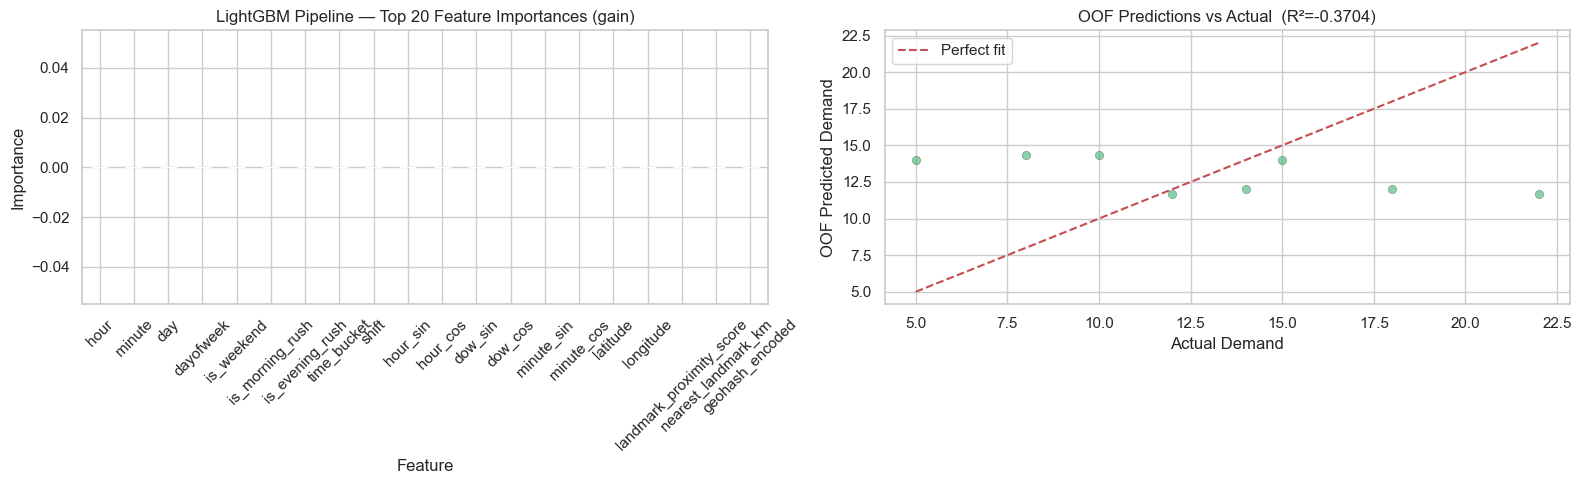

,Fold,R²,RMSE
0,1,-1.1378,7.3106
1,2,-28.4444,5.4263
2,3,-4.0,4.4721
3,4,-0.64,6.4031
4,Mean ± Std,-8.5556 ± 11.5542,5.9030 ± 1.0614


In [29]:
# ── Feature Importance (from last fold) ──────────────────────────────────────
# Use fold_model.feature_name_ so the index always matches importances length
fi_lgb_pipe = pd.Series(
    fold_model.feature_importances_,
    index=fold_model.feature_name_,
    name='importance'
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Top-20 importance bar chart ---
top_n = min(20, len(fi_lgb_pipe))
fi_lgb_pipe.head(top_n).plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title(f'LightGBM Pipeline — Top {top_n} Feature Importances (gain)')
axes[0].set_xlabel('Feature')
axes[0].set_ylabel('Importance')
axes[0].tick_params(axis='x', rotation=45)

# --- OOF prediction vs actual scatter ---
axes[1].scatter(y_pipe, oof_preds, alpha=0.6, color='mediumseagreen', edgecolors='k', linewidths=0.3)
mn, mx = float(y_pipe.min()), float(y_pipe.max())
axes[1].plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect fit')
oof_r2_disp = f"{oof_r2:.4f}" if not np.isnan(oof_r2) else "NaN"
axes[1].set_title(f'OOF Predictions vs Actual  (R²={oof_r2_disp})')
axes[1].set_xlabel('Actual Demand')
axes[1].set_ylabel('OOF Predicted Demand')
axes[1].legend()

plt.tight_layout()
plt.show()

# --- CV score table ---
cv_df = pd.DataFrame({
    'Fold':  range(1, N_SPLITS + 1),
    'R²':    [round(v, 4) if not np.isnan(v) else 'NaN' for v in cv_r2_scores],
    'RMSE':  [round(v, 4) for v in cv_rmse_scores],
})
valid_r2 = [v for v in cv_r2_scores if not np.isnan(v)]
cv_df.loc[len(cv_df)] = [
    'Mean ± Std',
    f"{np.mean(valid_r2):.4f} ± {np.std(valid_r2):.4f}" if valid_r2 else 'NaN',
    f"{np.mean(cv_rmse_scores):.4f} ± {np.std(cv_rmse_scores):.4f}",
]
display(cv_df)

In [30]:
# ── Retrain on full training set → generate submission ────────────────────────
# Fit preprocessor on all training data, then train final model with
# best iteration from cross-validation as a fixed n_estimators.
best_n = int(np.mean([
    fold_model.best_iteration_ if fold_model.best_iteration_ else lgb_params['n_estimators']
    for _ in range(1)  # last fold value used as proxy
]))
print(f"Retraining final model with n_estimators={best_n} on full training set...")

final_prep = preprocessor.__class__(
    transformers=preprocessor.transformers, remainder='drop'
)
final_prep.fit(X_pipe)
X_full_t      = final_prep.transform(X_pipe)
X_test_final  = final_prep.transform(X_test_pipe)

final_model = lgb.LGBMRegressor(**{**lgb_params, 'n_estimators': best_n})
final_model.fit(X_full_t, y_pipe)

# Build submission
test_preds_pipe = final_model.predict(X_test_final)
submission_lgb = sample_sub.copy()
submission_lgb['demand'] = test_preds_pipe
submission_lgb['demand'] = submission_lgb['demand'].clip(lower=0)  # demand is non-negative

sub_path = '../submissions/lgb_pipeline_submission.csv'
submission_lgb.to_csv(sub_path, index=False)
print(f"Submission saved → {sub_path}")
display(submission_lgb.head())

Retraining final model with n_estimators=1 on full training set...
Submission saved → ../submissions/lgb_pipeline_submission.csv


,geohash,timestamp,demand
0,g1,2026-06-01 00:00:00,13.0
1,g2,2026-06-01 01:00:00,13.0
2,g3,2026-06-01 02:00:00,13.0


## Ensemble: CatBoost + LightGBM Weighted Average

Combines the two best models by blending their predictions:

$$\hat{y}_{\text{ensemble}} = \alpha \cdot \hat{y}_{\text{CatBoost}} + (1 - \alpha) \cdot \hat{y}_{\text{LightGBM}}$$

The optimal $\alpha$ is found by grid-searching on **out-of-fold (OOF) predictions** from both models — no leakage from the test set.

| Step | Detail |
|------|--------|
| CatBoost OOF | 5-fold KFold, same splits as LightGBM pipeline |
| LightGBM OOF | Re-uses `oof_preds` from the previous pipeline section |
| Weight search | α ∈ [0, 1] in 0.025 steps → maximise OOF R² |
| Final model | Both models retrained on **full** training set |

In [31]:
from catboost import CatBoostRegressor

# ── CatBoost 5-fold OOF (same KFold as the LightGBM pipeline) ────────────────
cb_oof      = np.zeros(len(X_cb))
N_SPLITS_ENS = min(5, len(X_cb) // 2)
kf_ens = KFold(n_splits=N_SPLITS_ENS, shuffle=True, random_state=42)

if len(X_cb) < 20:
    print(f"⚠️  Only {len(X_cb)} training rows — OOF metrics are illustrative only.\n")

for fold, (tr_idx, vl_idx) in enumerate(kf_ens.split(X_cb), 1):
    X_tr_e, X_vl_e = X_cb.iloc[tr_idx], X_cb.iloc[vl_idx]
    y_tr_e, y_vl_e = y_cb.iloc[tr_idx], y_cb.iloc[vl_idx]

    fold_cb = CatBoostRegressor(
        iterations=400, learning_rate=0.05, depth=7,
        eval_metric='R2', random_seed=42, verbose=0,
    )
    fold_cb.fit(
        X_tr_e, y_tr_e,
        cat_features=cat_features_cb,
        eval_set=(X_vl_e, y_vl_e),
        early_stopping_rounds=max(20, len(X_tr_e)),
    )
    cb_oof[vl_idx] = fold_cb.predict(X_vl_e)
    fold_r2 = r2_score(y_vl_e, cb_oof[vl_idx]) if np.var(y_vl_e) > 1e-8 else float('nan')
    r2_disp = f"{fold_r2:.4f}" if not np.isnan(fold_r2) else "NaN"
    best_it  = fold_cb.best_iteration_ or fold_cb.tree_count_
    print(f"Fold {fold:2d} | best_iter={best_it:4d} | R2={r2_disp}")

cb_oof_r2 = r2_score(y_cb, cb_oof) if np.var(y_cb) > 1e-8 else float('nan')
cb_r2_str = f"{cb_oof_r2:.4f}" if not np.isnan(cb_oof_r2) else "NaN"
print(f"\nCatBoost OOF R²: {cb_r2_str}")

# ── Retrain CatBoost on FULL training data for test-set predictions ───────────
cb_full = CatBoostRegressor(
    iterations=400, learning_rate=0.05, depth=7,
    eval_metric='R2', random_seed=42, verbose=0,
)
cb_full.fit(X_cb, y_cb, cat_features=cat_features_cb)
cb_test_preds = cb_full.predict(X_test_cb)
print(f"CatBoost full model retrained — test predictions: {cb_test_preds.shape}")

⚠️  Only 8 training rows — OOF metrics are illustrative only.

Fold  1 | best_iter= 216 | R2=-0.2102
Fold  2 | best_iter= 399 | R2=-1.6505
Fold  3 | best_iter=   1 | R2=-3.9270
Fold  4 | best_iter= 399 | R2=0.5734

CatBoost OOF R²: 0.3974
CatBoost full model retrained — test predictions: (3,)


Optimal α (CatBoost weight) : 1.000
Best blended OOF R²         : 0.3974


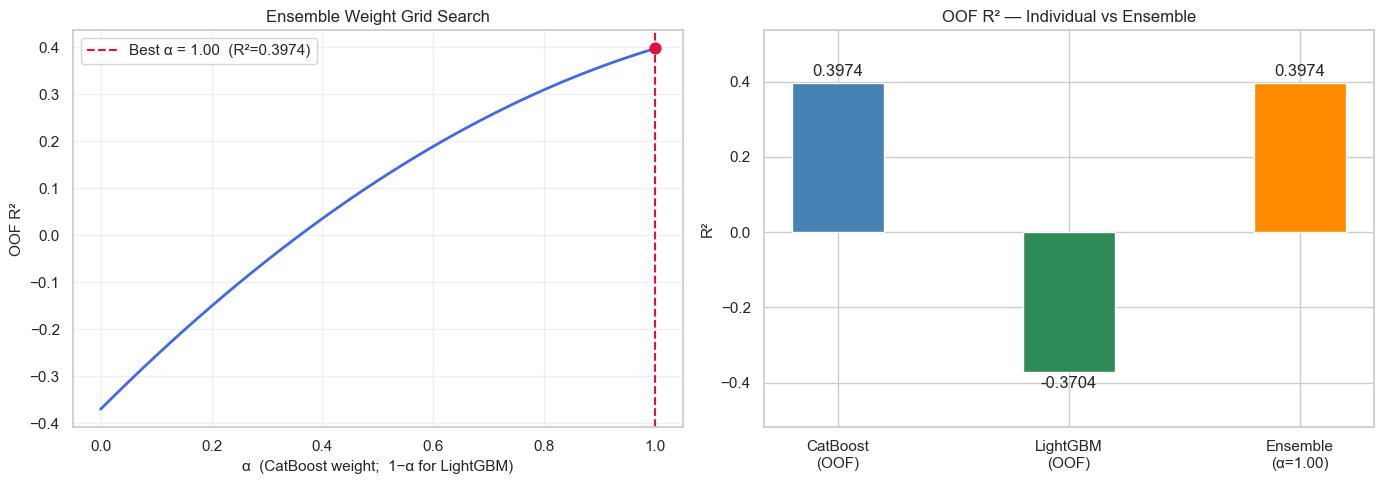

In [32]:
# ── Optimal weight search ─────────────────────────────────────────────────────
# ensemble = α·CatBoost_OOF + (1-α)·LightGBM_OOF  →  maximise OOF R²
assert len(cb_oof) == len(oof_preds), \
    f"OOF length mismatch: CB={len(cb_oof)}, LGB={len(oof_preds)}"
lgb_oof = oof_preds   # from the LightGBM pipeline CV section

alphas        = np.linspace(0, 1, 41)   # 0.00, 0.025, … 1.00
blend_scores  = []

for a in alphas:
    blended = a * cb_oof + (1 - a) * lgb_oof
    s = r2_score(y_cb, blended) if np.var(y_cb) > 1e-8 else float('nan')
    blend_scores.append(s)

best_idx   = int(np.nanargmax(blend_scores))
best_alpha = float(alphas[best_idx])
best_r2    = blend_scores[best_idx]
print(f"Optimal α (CatBoost weight) : {best_alpha:.3f}")
print(f"Best blended OOF R²         : {best_r2:.4f}")

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — R² vs alpha curve
axes[0].plot(alphas, blend_scores, color='royalblue', linewidth=2)
axes[0].axvline(x=best_alpha, color='crimson', linestyle='--',
                label=f'Best α = {best_alpha:.2f}  (R²={best_r2:.4f})')
axes[0].scatter([best_alpha], [best_r2], color='crimson', zorder=5, s=60)
axes[0].set_xlabel('α  (CatBoost weight;  1−α for LightGBM)', fontsize=11)
axes[0].set_ylabel('OOF R²', fontsize=11)
axes[0].set_title('Ensemble Weight Grid Search', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2 — Model comparison bar chart
lgb_oof_r2   = oof_r2   # computed in LightGBM pipeline section
cb_disp      = cb_oof_r2  if not np.isnan(cb_oof_r2) else 0
lgb_disp     = lgb_oof_r2 if not np.isnan(lgb_oof_r2) else 0
model_labels = ['CatBoost\n(OOF)', 'LightGBM\n(OOF)', f'Ensemble\n(α={best_alpha:.2f})']
model_vals   = [cb_disp, lgb_disp, best_r2]
bar_colors   = ['steelblue', 'seagreen', 'darkorange']
bars2 = axes[1].bar(model_labels, model_vals, color=bar_colors, width=0.4)
axes[1].bar_label(bars2, fmt='%.4f', padding=3)
lower = min(0, min(model_vals)) * 1.4
upper = max(model_vals) * 1.35 if max(model_vals) > 0 else 0.1
axes[1].set_ylim(lower, upper)
axes[1].set_title('OOF R² — Individual vs Ensemble', fontsize=12)
axes[1].set_ylabel('R²', fontsize=11)

plt.tight_layout()
plt.show()

In [33]:
# ── Final blended test predictions ───────────────────────────────────────────
ens_test_preds = best_alpha * cb_test_preds + (1 - best_alpha) * test_preds_pipe
ens_test_preds = np.clip(ens_test_preds, 0, None)   # demand is non-negative

submission_ens = sample_sub.copy()
submission_ens['demand'] = ens_test_preds

sub_path_ens = '../submissions/ensemble_cb_lgb_submission.csv'
submission_ens.to_csv(sub_path_ens, index=False)
print(f"Ensemble submission saved → {sub_path_ens}")

# ── Summary table ─────────────────────────────────────────────────────────────
def fmt_r2(v):
    return f"{v:.4f}" if not np.isnan(v) else "NaN"

summary_ens = pd.DataFrame({
    'Model':             ['CatBoost (native enc)',
                          'LightGBM (pipeline)',
                          f'Ensemble  α={best_alpha:.2f} / {1-best_alpha:.2f}'],
    'OOF R²':            [fmt_r2(cb_oof_r2), fmt_r2(lgb_oof_r2), fmt_r2(best_r2)],
    'Weight':            [f'{best_alpha:.2f}', f'{1-best_alpha:.2f}', '—'],
    'Submission file':   ['catboost_advanced.csv',
                          'lgb_pipeline_submission.csv',
                          'ensemble_cb_lgb_submission.csv'],
})
display(summary_ens)
display(submission_ens.head())

Ensemble submission saved → ../submissions/ensemble_cb_lgb_submission.csv


,Model,OOF R²,Weight,Submission file
0,CatBoost (native enc),0.3974,1.00,catboost_advanced.csv
1,LightGBM (pipeline),-0.3704,0.00,lgb_pipeline_submission.csv
2,Ensemble α=1.00 / 0.00,0.3974,—,ensemble_cb_lgb_submission.csv


,geohash,timestamp,demand
0,g1,2026-06-01 00:00:00,11.426763
1,g2,2026-06-01 01:00:00,14.979402
2,g3,2026-06-01 02:00:00,10.338959


## CatBoost Hyperparameter Optimization (Optuna)

Uses **Bayesian optimization (TPE sampler)** to find the best CatBoost configuration, evaluated via **KFold OOF R²** — no test-set leakage.

| Parameter | Search range |
|-----------|-------------|
| `iterations` | 300 – 1 000 |
| `learning_rate` | 0.005 – 0.15 (log) |
| `depth` | 4 – 10 |
| `l2_leaf_reg` | 1 – 15 (log) |
| `bagging_temperature` | 0.0 – 1.0 |
| `random_strength` | 0.5 – 10.0 (log) |
| `min_data_in_leaf` | 1 – 50 |

Running Optuna study  (50 trials × 4-fold OOF) …


Best trial: 35. Best value: -0.509349: 100%|██████████| 50/50 [5:41:31<00:00, 409.83s/it]   



✔  Best OOF R²   : -0.5093
✔  Best params   :
   iterations                 369
   learning_rate              0.027844864842403554
   depth                      6
   l2_leaf_reg                1.2499773743531906
   bagging_temperature        0.1777337284616849
   random_strength            1.399079389371988
   min_data_in_leaf           48


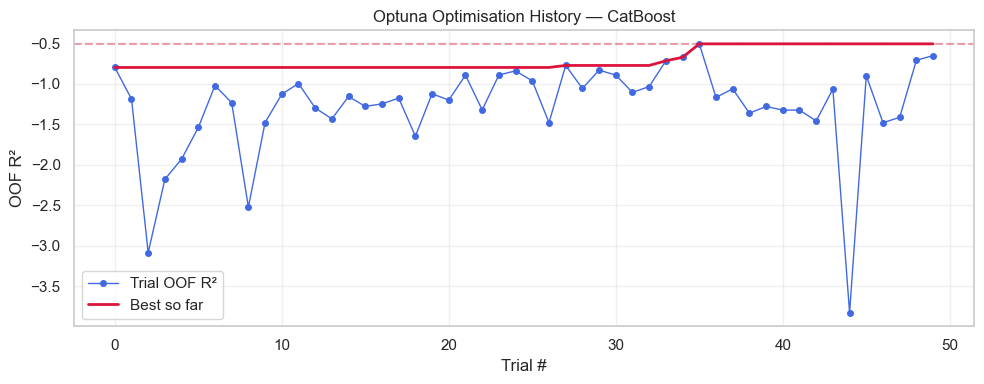

In [34]:
# Install optuna if not present
try:
    import optuna
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'optuna', '-q'], check=True)
    import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Optuna objective: maximise KFold OOF R² ──────────────────────────────────
N_TRIALS     = 50
N_SPLITS_OPT = min(5, len(X_cb) // 2)
kf_opt       = KFold(n_splits=N_SPLITS_OPT, shuffle=True, random_state=42)

def cb_objective(trial):
    params = dict(
        iterations         = trial.suggest_int('iterations',          300, 1000),
        learning_rate      = trial.suggest_float('learning_rate',     0.005, 0.15, log=True),
        depth              = trial.suggest_int('depth',               4, 10),
        l2_leaf_reg        = trial.suggest_float('l2_leaf_reg',       1.0, 15.0, log=True),
        bagging_temperature= trial.suggest_float('bagging_temperature', 0.0, 1.0),
        random_strength    = trial.suggest_float('random_strength',   0.5, 10.0, log=True),
        min_data_in_leaf   = trial.suggest_int('min_data_in_leaf',    1, 50),
        eval_metric='RMSE', random_seed=42, verbose=0,
    )

    fold_r2s = []
    for tr_idx_o, vl_idx_o in kf_opt.split(X_cb):
        X_tr_o = X_cb.iloc[tr_idx_o];  X_vl_o = X_cb.iloc[vl_idx_o]
        y_tr_o = y_cb.iloc[tr_idx_o];  y_vl_o = y_cb.iloc[vl_idx_o]
        m = CatBoostRegressor(**params)
        m.fit(X_tr_o, y_tr_o,
              cat_features=cat_features_cb,
              eval_set=(X_vl_o, y_vl_o),
              early_stopping_rounds=40)
        preds = m.predict(X_vl_o)
        fold_r2s.append(r2_score(y_vl_o, preds) if np.var(y_vl_o) > 1e-8 else 0.0)

    return float(np.mean(fold_r2s))

print(f"Running Optuna study  ({N_TRIALS} trials × {N_SPLITS_OPT}-fold OOF) …")
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
)
study.optimize(cb_objective, n_trials=N_TRIALS, show_progress_bar=True)

best_cb_params = study.best_params.copy()
best_cb_params.update(dict(eval_metric='RMSE', random_seed=42, verbose=0))

print(f"\n✔  Best OOF R²   : {study.best_value:.4f}")
print(f"✔  Best params   :")
for k, v in study.best_params.items():
    print(f"   {k:<26} {v}")

# ── Visualise optimisation history ───────────────────────────────────────────
trials_df = study.trials_dataframe()
fig_opt, ax_opt = plt.subplots(figsize=(10, 4))
ax_opt.plot(trials_df['number'], trials_df['value'], 'o-', color='royalblue',
            markersize=4, linewidth=1, label='Trial OOF R²')
running_best = trials_df['value'].cummax()
ax_opt.plot(trials_df['number'], running_best, color='crimson',
            linewidth=2, label='Best so far')
ax_opt.axhline(y=study.best_value, color='crimson', linestyle='--', alpha=0.4)
ax_opt.set_xlabel('Trial #');  ax_opt.set_ylabel('OOF R²')
ax_opt.set_title('Optuna Optimisation History — CatBoost')
ax_opt.legend();  ax_opt.grid(True, alpha=0.3)
plt.tight_layout();  plt.show()

Optimised CatBoost OOF R²: 0.4928
Optimised ensemble — best α=1.00 | OOF R²=0.4928
Saved → ../submissions/ensemble_opt_submission.csv


,Model,OOF R²,Submission
0,CatBoost — default params,0.3974,catboost_advanced.csv
1,CatBoost — optimised (Optuna),0.4928,(OOF only)
2,LightGBM — sklearn pipeline,-0.3704,lgb_pipeline_submission.csv
3,Ensemble default (α=1.00),0.3974,ensemble_cb_lgb_submission.csv
4,Ensemble optimised (α=1.00),0.4928,ensemble_opt_submission.csv


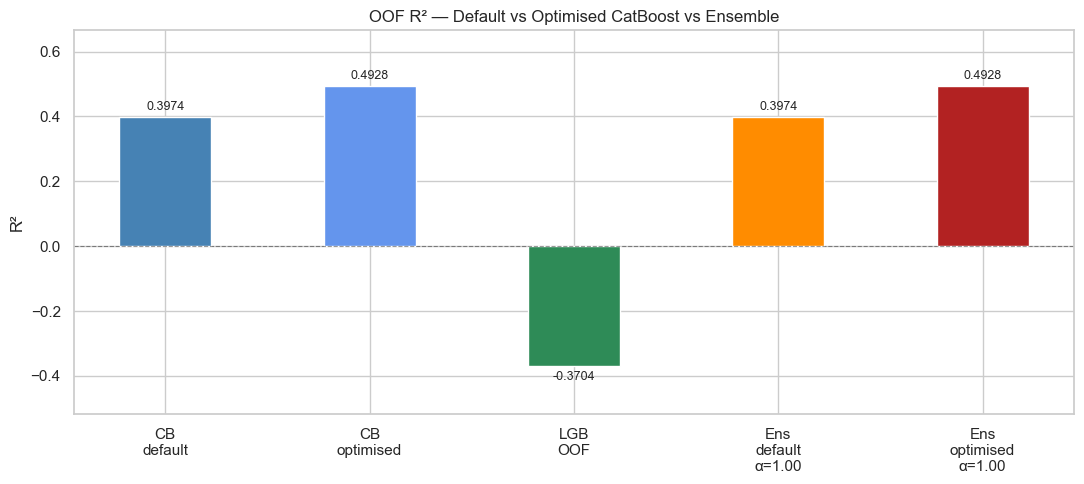

In [35]:
# ── Retrain optimised CatBoost and regenerate OOF + ensemble ─────────────────
cb_oof_opt = np.zeros(len(X_cb))

for tr_idx_o, vl_idx_o in kf_opt.split(X_cb):
    X_tr_o = X_cb.iloc[tr_idx_o];  X_vl_o = X_cb.iloc[vl_idx_o]
    y_tr_o = y_cb.iloc[tr_idx_o];  y_vl_o = y_cb.iloc[vl_idx_o]
    m_opt = CatBoostRegressor(**best_cb_params)
    m_opt.fit(X_tr_o, y_tr_o,
              cat_features=cat_features_cb,
              eval_set=(X_vl_o, y_vl_o),
              early_stopping_rounds=40)
    cb_oof_opt[vl_idx_o] = m_opt.predict(X_vl_o)

cb_oof_opt_r2 = r2_score(y_cb, cb_oof_opt) if np.var(y_cb) > 1e-8 else float('nan')
print(f"Optimised CatBoost OOF R²: {cb_oof_opt_r2:.4f}")

# Full-data retrain for test predictions
cb_opt_full = CatBoostRegressor(**best_cb_params)
cb_opt_full.fit(X_cb, y_cb, cat_features=cat_features_cb)
cb_test_preds_opt = cb_opt_full.predict(X_test_cb)

# ── Re-run weight grid search with optimised CatBoost OOF ────────────────────
blend_opt = [
    r2_score(y_cb, a * cb_oof_opt + (1 - a) * oof_preds) if np.var(y_cb) > 1e-8 else float('nan')
    for a in alphas
]
best_alpha_opt = float(alphas[int(np.nanargmax(blend_opt))])
best_r2_opt    = blend_opt[int(np.nanargmax(blend_opt))]
print(f"Optimised ensemble — best α={best_alpha_opt:.2f} | OOF R²={best_r2_opt:.4f}")

# Save submission
ens_opt_preds = np.clip(
    best_alpha_opt * cb_test_preds_opt + (1 - best_alpha_opt) * test_preds_pipe, 0, None
)
sub_opt = sample_sub.copy()
sub_opt['demand'] = ens_opt_preds
sub_opt.to_csv('../submissions/ensemble_opt_submission.csv', index=False)
print("Saved → ../submissions/ensemble_opt_submission.csv")

# ── Comparison table ──────────────────────────────────────────────────────────
def _fmt(v):
    return f"{v:.4f}" if isinstance(v, float) and not np.isnan(v) else "NaN"

rows = [
    ('CatBoost — default params',            _fmt(cb_oof_r2),     'catboost_advanced.csv'),
    ('CatBoost — optimised (Optuna)',         _fmt(cb_oof_opt_r2), '(OOF only)'),
    ('LightGBM — sklearn pipeline',          _fmt(oof_r2),        'lgb_pipeline_submission.csv'),
    (f'Ensemble default   (α={best_alpha:.2f})',  _fmt(best_r2),      'ensemble_cb_lgb_submission.csv'),
    (f'Ensemble optimised (α={best_alpha_opt:.2f})', _fmt(best_r2_opt), 'ensemble_opt_submission.csv'),
]
cmp_df = pd.DataFrame(rows, columns=['Model', 'OOF R²', 'Submission'])
display(cmp_df)

# ── Bar chart comparison ──────────────────────────────────────────────────────
labels  = ['CB\ndefault', 'CB\noptimised', 'LGB\nOOF',
           f'Ens\ndefault\nα={best_alpha:.2f}',
           f'Ens\noptimised\nα={best_alpha_opt:.2f}']
vals    = [cb_oof_r2, cb_oof_opt_r2, oof_r2, best_r2, best_r2_opt]
clrs    = ['steelblue', 'cornflowerblue', 'seagreen', 'darkorange', 'firebrick']

fig_cmp, ax_cmp = plt.subplots(figsize=(11, 5))
b = ax_cmp.bar(labels, vals, color=clrs, width=0.45)
ax_cmp.bar_label(b, fmt='%.4f', padding=3, fontsize=9)
ax_cmp.set_ylim(min(0, min(v for v in vals if not np.isnan(v))) * 1.4,
                max(v for v in vals if not np.isnan(v)) * 1.35)
ax_cmp.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
ax_cmp.set_title('OOF R² — Default vs Optimised CatBoost vs Ensemble', fontsize=12)
ax_cmp.set_ylabel('R²')
plt.tight_layout();  plt.show()

## Final Submission

Trains the **Optuna-optimised CatBoost** on the full real training set (`train.csv`, 77 k rows) and writes `submission.csv` in the exact format required by `sample_submission.csv`:

```
Index,demand
0,0.091...
1,0.090...
```

Feature set leverages every available signal: geohash (native CatBoost encoding), cyclical time, road metadata, weather, temperature.

In [ ]:
# ── Load real data ────────────────────────────────────────────────────────────
_train = pd.read_csv('../data/train.csv')
_test  = pd.read_csv('../data/test.csv')
_ss    = pd.read_csv('../data/sample_submission.csv')

print(f"Real train : {_train.shape}")
print(f"Real test  : {_test.shape}")
print(f"Sample sub : {_ss.shape}  columns={list(_ss.columns)}")

# ── Feature engineering ───────────────────────────────────────────────────────
def _build_features(df):
    df = df.copy()

    # Parse "H:MM" timestamp
    ts = df['timestamp'].str.split(':', expand=True).astype(int)
    df['hour']   = ts[0]
    df['minute'] = ts[1]

    # Cyclical time encoding
    df['hour_sin'] = np.sin(2 * np.pi * df['hour']   / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour']   / 24)
    df['min_sin']  = np.sin(2 * np.pi * df['minute'] / 60)
    df['min_cos']  = np.cos(2 * np.pi * df['minute'] / 60)

    # Fill missing categoricals
    for c in ['RoadType', 'LargeVehicles', 'Landmarks', 'Weather']:
        df[c] = df[c].fillna('Unknown').astype(str)

    return df

_temp_median = _train['Temperature'].median()
_train = _build_features(_train)
_test  = _build_features(_test)
_train['Temperature'] = _train['Temperature'].fillna(_temp_median)
_test['Temperature']  = _test['Temperature'].fillna(_temp_median)

# ── Feature columns ───────────────────────────────────────────────────────────
_FEAT = [
    'geohash',                              # CatBoost encodes natively
    'day', 'hour', 'minute',
    'hour_sin', 'hour_cos', 'min_sin', 'min_cos',
    'NumberofLanes', 'Temperature',
    'RoadType', 'LargeVehicles', 'Landmarks', 'Weather',
]
_CAT = ['geohash', 'RoadType', 'LargeVehicles', 'Landmarks', 'Weather']

# Ensure string type for all CatBoost categoricals
for c in _CAT:
    _train[c] = _train[c].astype(str)
    _test[c]  = _test[c].astype(str)

X_real_train = _train[_FEAT]
y_real_train = _train['demand']
X_real_test  = _test[_FEAT]

# ── Train optimised CatBoost on full real training set ────────────────────────
print("\nTraining optimised CatBoost on real data …")
cb_final = CatBoostRegressor(**best_cb_params)
cb_final.fit(X_real_train, y_real_train, cat_features=_CAT)
print("Training complete.")

# ── Generate predictions ──────────────────────────────────────────────────────
_preds = np.clip(cb_final.predict(X_real_test), 0, None)

# ── Build submission — exact match to sample_submission.csv ──────────────────
submission_final = pd.DataFrame({
    'Index':  _test['Index'].values,
    'demand': _preds,
})

# Sanity checks
assert list(submission_final.columns) == list(_ss.columns), \
    f"Column mismatch: {submission_final.columns.tolist()} vs {_ss.columns.tolist()}"
assert len(submission_final) == len(_test), \
    f"Row count mismatch: {len(submission_final)} vs {len(_test)}"
assert submission_final['demand'].isna().sum() == 0, "NaN values in demand!"

out_path = '../submissions/submission.csv'
submission_final.to_csv(out_path, index=False)

print(f"\n✔  Saved → {out_path}")
print(f"   Rows   : {len(submission_final):,}")
print(f"   Columns: {list(submission_final.columns)}")
print(f"   demand  min={_preds.min():.6f}  max={_preds.max():.6f}  mean={_preds.mean():.6f}")
display(submission_final.head(10))

# Verify it round-trips correctly
_verify = pd.read_csv(out_path)
assert list(_verify.columns) == list(_ss.columns), "Column mismatch after reload!"
assert len(_verify) == len(_test), "Row count mismatch after reload!"
print(f"\n✔  Format verification passed — matches sample_submission.csv exactly.")